# Modeling - With C1 vs C3 vs C4 possible improvements
Adding new features
`tilt_distance_ratio`
`neighbor_competition =avg_neighbor_advantage *overlap_ratio`
`overlap_sinr_penalty`

In [53]:
import numpy as np
import statsmodels.api as sm

print(np.__version__)
print(sm.__version__)

1.26.4
0.14.6


In [74]:
!pip install "numpy<2" --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.0 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [54]:
import json
import re
import math
import numpy as np
import pandas as pd
from io import StringIO

## Feature Engineering

In [55]:
def parse_tables(question):
    text = question.replace("\r\n", "\n").replace("\r", "\n")

    user_match = re.search(
        r"User plane drive test data as follows[：:]\s*\n+(.*?)(?:\n\s*\n\s*Engeneering parameters data as follows[：:]|\n\s*\n\s*Engineering parameters data as follows[：:])",
        text,
        flags=re.S
    )

    eng_match = re.search(
        r"(?:Engeneering|Engineering) parameters data as follows[：:]\s*\n+(.*)$",
        text,
        flags=re.S
    )

    if not user_match or not eng_match:
        raise ValueError("Could not find table blocks")

    def block_to_df(block):
        lines = []
        for line in block.splitlines():
            line = line.strip()
            if "|" in line:
                lines.append(line)

        # Repairs rare formatting issue like "g\nNodeB ID"
        if lines and lines[0].startswith("NodeB ID|"):
            lines[0] = "g" + lines[0]

        return pd.read_csv(StringIO("\n".join(lines)), sep="|")

    user_df = block_to_df(user_match.group(1))
    eng_df = block_to_df(eng_match.group(1))

    return user_df, eng_df


def beamwidth_from_scenario(s):
    if pd.isna(s):
        return np.nan

    s = str(s).upper()

    if "DEFAULT" in s:
        return 6

    match = re.search(r"SCENARIO_(\d+)", s)
    if match:
        n = int(match.group(1))
        if n <= 5:
            return 6
        elif n <= 11:
            return 12
        else:
            return 25

    return np.nan

# Calculate distance between vehicle GPS location and tower location
# C2: coverage distance exceeds 1 km -> To calculate distance
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0

    lon1, lat1, lon2, lat2 = map(
        np.radians,
        [lon1, lat1, lon2, lat2]
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

# longest consecutive streak of low throughput
def longest_streak_bool(values):
    max_streak = 0
    current = 0

    for value in values:
        if bool(value):
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0

    return max_streak

def make_features(user_df, eng_df):
    # Taking care of missing data "-" as NaN
    user_df = user_df.copy().replace("-", np.nan)
    eng_df = eng_df.copy().replace("-", np.nan)

    # Define important column names
    tp_col = "5G KPI PCell Layer2 MAC DL Throughput [Mbps]"
    speed_col = "GPS Speed (km/h)"
    # "What cell is the UE connected to?"
    pci_col = "5G KPI PCell RF Serving PCI"
    # "How strong is the signal?"
    rsrp_col = "5G KPI PCell RF Serving SS-RSRP [dBm]"
    # "How clean is the signal?"
    sinr_col = "5G KPI PCell RF Serving SS-SINR [dB]"
    # "How many RBs are being used?"
    rb_col = "5G KPI PCell Layer1 DL RB Num (Including 0)"

    neighbor_pci_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} PCI"
        for i in range(1, 6)
    ]

    neighbor_brsrp_cols = [
        f"Measurement PCell Neighbor Cell Top Set(Cell Level) Top {i} Filtered Tx BRSRP [dBm]"
        for i in range(1, 6)
    ]

    numeric_user_cols = [
        "Longitude", "Latitude",
        tp_col, speed_col, pci_col, rsrp_col, sinr_col, rb_col
    ] + neighbor_pci_cols + neighbor_brsrp_cols

    # Convert text numbers into numeric values
    for col in numeric_user_cols:
        if col in user_df.columns:
            user_df[col] = pd.to_numeric(user_df[col], errors="coerce")

    numeric_eng_cols = [
        "Longitude", "Latitude", "Mechanical Downtilt",
        "Digital Tilt", "Height", "PCI"
    ]

    for col in numeric_eng_cols:
        eng_df[col] = pd.to_numeric(eng_df[col], errors="coerce")

    # Engineering transformations
    # we replace 255 with 6.
    eng_df["digital_tilt_clean"] = eng_df["Digital Tilt"].replace(255, 6)
    # effective_tilt = mechanical downtilt + digital tilt -> Can be useful for C1: downtilt too large
    eng_df["effective_tilt"] = (
        eng_df["Mechanical Downtilt"] + eng_df["digital_tilt_clean"]
    )
    eng_df["beamwidth"] = eng_df["Beam Scenario"].apply(beamwidth_from_scenario)

    #print("Engineering data after transformations:")
    #print(eng_df)

    eng_by_pci = (
        eng_df
        .dropna(subset=["PCI"])
        .drop_duplicates("PCI")
        .set_index("PCI")
    )

    features = {}

    tp = user_df[tp_col]
    low_mask = tp < 600
    low_df = user_df[low_mask]

    # -----------------------------
    # Throughput features
    # -----------------------------
    features["avg_throughput"] = tp.mean()
    features["min_throughput"] = tp.min()
    features["std_throughput"] = tp.std()
    features["low_tp_count"] = int(low_mask.sum())
    features["low_tp_ratio"] = low_mask.mean()
    features["avg_throughput_low_tp"] = low_df[tp_col].mean()
    features["consecutive_low_tp_max"] = longest_streak_bool(low_mask.tolist())

    # -----------------------------
    # Speed features
    # -----------------------------
    speed = user_df[speed_col]

    features["max_speed"] = speed.max()
    features["pct_speed_above_40"] = (speed > 40).mean()
    features["avg_speed_low_tp"] = low_df[speed_col].mean()
    features["max_speed_low_tp"] = low_df[speed_col].max()

    # -----------------------------
    # Handover features
    # -----------------------------
    serving_pci = user_df[pci_col]

    features["num_unique_serving_pci"] = serving_pci.nunique()

    switches = (
        (serving_pci != serving_pci.shift())
        & serving_pci.notna()
        & serving_pci.shift().notna()
    )

    features["handover_count"] = int(switches.sum())
    features["handover_rate"] = features["handover_count"] / max(len(user_df) - 1, 1)

    if len(low_df) > 1:
        low_pci = low_df[pci_col]
        low_switches = (
            (low_pci != low_pci.shift())
            & low_pci.notna()
            & low_pci.shift().notna()
        )
        features["handover_count_low_tp"] = int(low_switches.sum())
    else:
        features["handover_count_low_tp"] = 0

    # -----------------------------
    # Signal quality features
    # -----------------------------
    features["avg_rsrp"] = user_df[rsrp_col].mean()
    features["min_rsrp"] = user_df[rsrp_col].min()
    features["avg_rsrp_low_tp"] = low_df[rsrp_col].mean()

    features["avg_sinr"] = user_df[sinr_col].mean()
    features["min_sinr"] = user_df[sinr_col].min()
    features["avg_sinr_low_tp"] = low_df[sinr_col].mean()


    # NEW SINR FEATURES
    features["std_sinr"] = user_df[sinr_col].std()

    SINR_THRESHOLD = 5
    features["pct_sinr_below_5"] = (user_df[sinr_col] < SINR_THRESHOLD).mean()

    features["min_sinr_low_tp"] = low_df[sinr_col].min()

    # -----------------------------
    # RB features
    # -----------------------------
    rb = user_df[rb_col]

    features["avg_rb"] = rb.mean()
    features["min_rb"] = rb.min()
    features["avg_rb_low_tp"] = low_df[rb_col].mean()
    features["min_rb_low_tp"] = low_df[rb_col].min()
    features["pct_rb_below_160"] = (rb < 160).mean()
    

    # -----------------------------
    # Neighbor + PCI mod 30 features
    # -----------------------------
    neighbor_advantages = []
    neighbor_stronger_flags = []
    close_neighbor_counts = []
    same_mod30_flags = []
    same_mod30_counts = []

    for _, row in user_df.iterrows():
        serving_rsrp = row[rsrp_col]
        serving_pci_value = row[pci_col]

        neighbor_brsrps = [
            row[col] for col in neighbor_brsrp_cols
            if col in user_df.columns and pd.notna(row[col])
        ]

        neighbor_pcis = [
            row[col] for col in neighbor_pci_cols
            if col in user_df.columns
        ]

        # Neighbor strength
        if neighbor_brsrps and pd.notna(serving_rsrp):
            strongest_neighbor = max(neighbor_brsrps)
            advantage = strongest_neighbor - serving_rsrp

            neighbor_advantages.append(advantage)
            neighbor_stronger_flags.append(strongest_neighbor > serving_rsrp)

            close_count = sum(
                abs(x - serving_rsrp) <= 3
                for x in neighbor_brsrps
            )
            close_neighbor_counts.append(close_count)

        # PCI mod 30 conflict
        mod30_count = 0

        if pd.notna(serving_pci_value):
            for neighbor_pci in neighbor_pcis:
                if pd.notna(neighbor_pci):
                    if int(neighbor_pci) % 30 == int(serving_pci_value) % 30:
                        mod30_count += 1

        same_mod30_counts.append(mod30_count)
        same_mod30_flags.append(mod30_count > 0)

    features["avg_neighbor_advantage"] = (
        np.nanmean(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["max_neighbor_advantage"] = (
        np.nanmax(neighbor_advantages) if neighbor_advantages else np.nan
    )
    features["neighbor_stronger_ratio"] = (
        np.mean(neighbor_stronger_flags) if neighbor_stronger_flags else np.nan
    )
    features["avg_close_neighbor_count"] = (
        np.nanmean(close_neighbor_counts) if close_neighbor_counts else np.nan
    )
    features["overlap_ratio"] = (
        np.mean([x > 0 for x in close_neighbor_counts])
        if close_neighbor_counts else np.nan
    )

    features["same_mod30_exists"] = int(any(same_mod30_flags))
    features["same_mod30_count"] = np.sum(same_mod30_counts)
    features["same_mod30_ratio"] = np.mean(same_mod30_flags)

    # ----------------------------------------
    # neighbor_competition = avg_neighbor_advantage * overlap_ratio
    # ----------------------------------------
    neighbor_adv = features.get(
    "avg_neighbor_advantage",
        np.nan
    )

    overlap = features.get(
        "overlap_ratio",
        np.nan
    )

    features["neighbor_competition"] = (
        neighbor_adv * overlap
        if pd.notna(neighbor_adv)
        and pd.notna(overlap)
        else np.nan
    )

    # ----------------------------------------
    # TxRx Mode (categorical)
    # ----------------------------------------

    txrx_vals = eng_df["TxRx Mode"].dropna()

    features["txrx_mode"] = (
        txrx_vals.mode().iloc[0]
        if len(txrx_vals) > 0
        else "Unknown"
    )

    # ----------------------------------------
    # Antenna Model (categorical)
    # ----------------------------------------

    antenna_vals = eng_df["Antenna Model"].dropna()

    features["antenna_model"] = (
        antenna_vals.mode().iloc[0]
        if len(antenna_vals) > 0
        else "Unknown"
    )

    # -----------------------------
    # Engineering + distance features
    # -----------------------------
    serving_tilts = []
    serving_beamwidths = []
    serving_heights = []
    serving_distances = []
    serving_distances_low_tp = []

    for idx, row in user_df.iterrows():
        serving_pci_value = row[pci_col]

        if pd.notna(serving_pci_value) and serving_pci_value in eng_by_pci.index:
            eng_row = eng_by_pci.loc[serving_pci_value]

            serving_tilts.append(eng_row["effective_tilt"])
            serving_beamwidths.append(eng_row["beamwidth"])
            serving_heights.append(eng_row["Height"])

            dist = haversine(
                row["Longitude"],
                row["Latitude"],
                eng_row["Longitude"],
                eng_row["Latitude"]
            )

            serving_distances.append(dist)

            if low_mask.iloc[idx]:
                serving_distances_low_tp.append(dist)

    features["avg_serving_tilt"] = (
        np.nanmean(serving_tilts) if serving_tilts else np.nan
    )
    features["max_serving_tilt"] = (
        np.nanmax(serving_tilts) if serving_tilts else np.nan
    )
    features["avg_serving_beamwidth"] = (
        np.nanmean(serving_beamwidths) if serving_beamwidths else np.nan
    )
    features["avg_serving_height"] = (
        np.nanmean(serving_heights) if serving_heights else np.nan
    )

    features["avg_serving_distance_km"] = (
        np.nanmean(serving_distances) if serving_distances else np.nan
    )
    features["max_serving_distance_km"] = (
        np.nanmax(serving_distances) if serving_distances else np.nan
    )
    features["pct_distance_gt_1km"] = (
        np.mean([d > 1 for d in serving_distances])
        if serving_distances else np.nan
    )
    features["avg_distance_low_tp"] = (
        np.nanmean(serving_distances_low_tp)
        if serving_distances_low_tp else np.nan
    )

    # C1 feature:
    # excessive tilt + weak signal

    features["tilt_rsrp_interaction"] = (
        features["avg_serving_tilt"]
        *
        abs(features["min_rsrp"])
    )


    return features


In [56]:
with open("../data/train.json", "r") as f:
    train = json.load(f)

rows = []

for item in train:
    user_df, eng_df = parse_tables(item["question"])
    features = make_features(user_df, eng_df)
    features["answer"] = item["answer"]
    rows.append(features)

ml_df = pd.DataFrame(rows)

print(ml_df.shape)
print(ml_df.head())
print(ml_df["answer"].value_counts())

# Optional: save engineered dataset
ml_df.to_csv("telelogs_engineered_features.csv", index=False)

(2400, 50)
   avg_throughput  min_throughput  std_throughput  low_tp_count  low_tp_ratio  \
0         847.792          334.00      407.163069             4           0.4   
1         850.051          388.58      345.211857             4           0.4   
2         671.739          258.08      295.071300             4           0.4   
3         921.430          407.35      399.562308             4           0.4   
4         789.406          319.87      366.988478             4           0.4   

   avg_throughput_low_tp  consecutive_low_tp_max  max_speed  \
0               424.7125                       4         33   
1               470.3825                       4         33   
2               338.5225                       4         36   
3               459.8275                       4         32   
4               404.2275                       4         32   

   pct_speed_above_40  avg_speed_low_tp  ...  avg_serving_tilt  \
0                 0.0             12.75  ...             

## C1 vs C3 EDA

In [6]:
ml_df["tilt_rsrp_interaction"] = (
        ml_df["avg_serving_tilt"]
        *
        abs(ml_df["min_rsrp"])
    )

In [7]:
ml_df["answer"].isin(
        ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]
    )


0       True
1       True
2       True
3       True
4       True
        ... 
2395    True
2396    True
2397    True
2398    True
2399    True
Name: answer, Length: 2400, dtype: bool

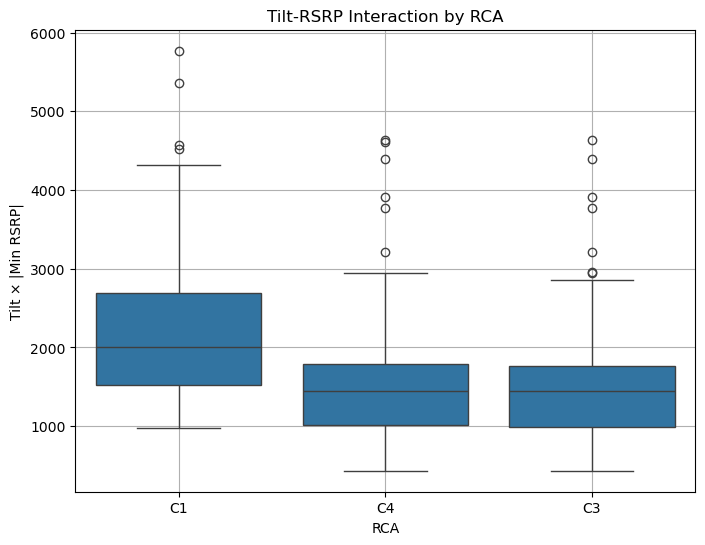

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

subset = ml_df[
    ml_df["answer"].isin(
        ["C1", "C3", "C4"]
    )
]

plt.figure(figsize=(8,6))


sns.boxplot(
    data=subset,
    x="answer",
    y="tilt_rsrp_interaction",
)

plt.title(
    "Tilt-RSRP Interaction by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Tilt × |Min RSRP|"
)

plt.grid(True)
plt.show()

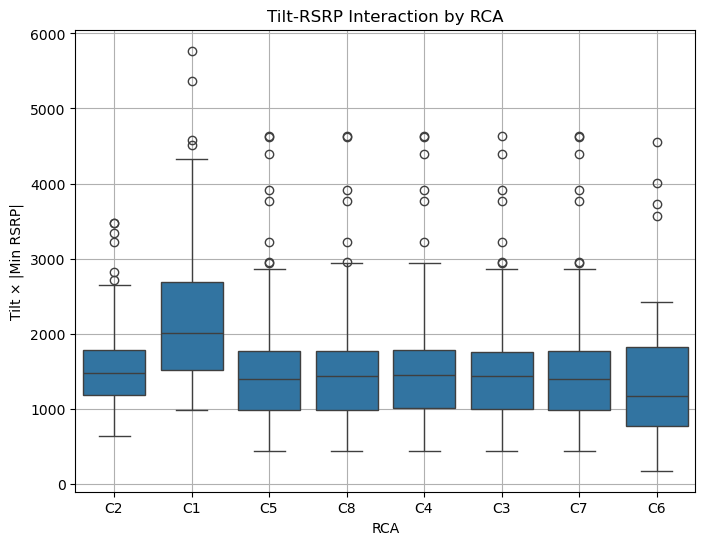

In [11]:
subset = ml_df[
    ml_df["answer"].isin(
        ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]
    )
]

plt.figure(figsize=(8,6))


sns.boxplot(
    data=subset,
    x="answer",
    y="tilt_rsrp_interaction",
)

plt.title(
    "Tilt-RSRP Interaction by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Tilt × |Min RSRP|"
)

plt.grid(True)
plt.show()

In [12]:
print(
    ml_df["min_rsrp"].describe()
)

count    2400.000000
mean      -88.591342
std         1.597387
min       -94.720000
25%       -89.350000
50%       -88.630000
75%       -87.610000
max       -85.000000
Name: min_rsrp, dtype: float64


C1 showed noticeably higher tilt-RSRP interaction values
Better separation was observed between C1 and neighboring-cell related issues (C3/C4)
Min rsrp are negative values. The higher absolute of min_rsrp value the it means it actually had the lowest rsrp which means the lowest signal.


## C3 vs C4

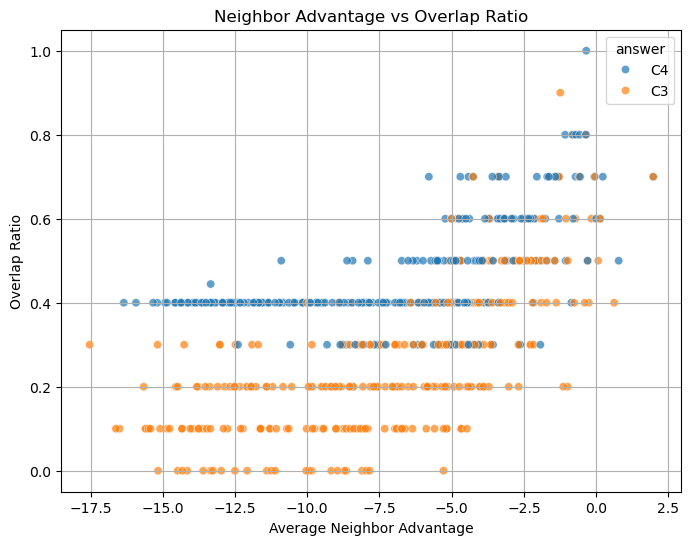

In [83]:
subset = ml_df[
    ml_df["answer"].isin(
        ["C3", "C4"]
    )
]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=subset,
    x="avg_neighbor_advantage",
    y="overlap_ratio",
    hue="answer",
    alpha=0.7
)

plt.title(
    "Neighbor Advantage vs Overlap Ratio"
)
plt.xlabel(
    "Average Neighbor Advantage"
)
plt.ylabel(
    "Overlap Ratio"
)

plt.grid(True)
plt.show()

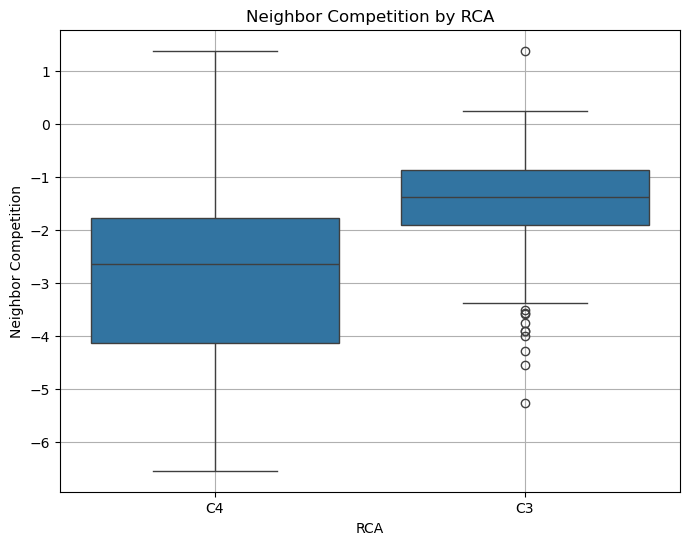

In [84]:
ml_df["neighbor_competition"] = (
    ml_df["avg_neighbor_advantage"]
    *
    ml_df["overlap_ratio"]
)

subset = ml_df[
    ml_df["answer"].isin(
        ["C3", "C4"]
    )
]

plt.figure(figsize=(8,6))

sns.boxplot(
    data=subset,
    x="answer",
    y="neighbor_competition"
)

plt.title(
    "Neighbor Competition by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Neighbor Competition"
)

plt.grid(True)
plt.show()

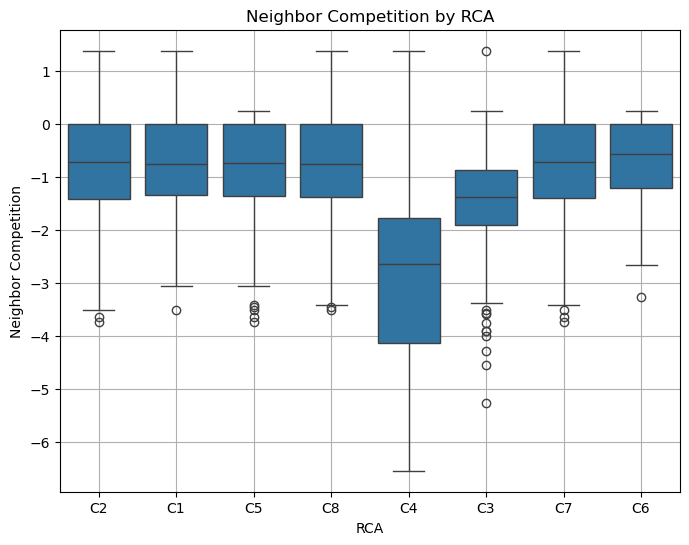

In [85]:
ml_df["neighbor_competition"] = (
    ml_df["avg_neighbor_advantage"]
    *
    ml_df["overlap_ratio"]
)

subset = ml_df[
    ml_df["answer"].isin(
        ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"]
    )
]

plt.figure(figsize=(8,6))

sns.boxplot(
    data=subset,
    x="answer",
    y="neighbor_competition"
)

plt.title(
    "Neighbor Competition by RCA"
)

plt.xlabel("RCA")
plt.ylabel(
    "Neighbor Competition"
)

plt.grid(True)
plt.show()

C4: was overlapping from neiboring cells
much lower (more negative)
neighbor competition


* C4 demonstrated the strongest overlap-driven neighbor interaction, supporting its interpretation as a severe co-frequency overlap issue.
* C3 exhibited moderate neighbor competition, aligning with a stronger neighboring-cell scenario rather than widespread interference.
* Neighbor competition showed improved class-specific separation for C3/C4 compared with other RCA classes, suggesting potential value for reducing model confusion between neighboring-cell-related failures.

## 1. Logistic Regression

### Seperate Explanatory variables and a Target Variable

In [57]:
X = ml_df.drop("answer", axis=1)
y = ml_df["answer"]

In [58]:
from sklearn.impute import SimpleImputer
import pandas as pd

# -----------------------------
# Numeric & categorical split
# -----------------------------

numeric_cols = X.select_dtypes(include=["number"]).columns
categorical_cols = X.select_dtypes(exclude=["number"]).columns

# Numeric
num_imputer = SimpleImputer(strategy="median")

X_numeric = pd.DataFrame(
    num_imputer.fit_transform(X[numeric_cols]),
    columns=numeric_cols,
    index=X.index
)

# Categorical
cat_imputer = SimpleImputer(strategy="most_frequent")

X_categorical = pd.DataFrame(
    cat_imputer.fit_transform(X[categorical_cols]),
    columns=categorical_cols,
    index=X.index
)

# Combine
X_imputed = pd.concat(
    [X_numeric, X_categorical],
    axis=1
)

X_imputed

,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,max_serving_tilt,avg_serving_beamwidth,avg_serving_height,avg_serving_distance_km,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,tilt_rsrp_interaction,txrx_mode,antenna_model
0,847.792,334.00,407.163069,4.0,0.4,424.7125,4.0,33.0,0.0,12.75,...,14.0,6.0,14.88,1.122599,2.774421,0.4,2.771672,1164.372,64T64R,NR AAU 2
1,850.051,388.58,345.211857,4.0,0.4,470.3825,4.0,33.0,0.0,12.75,...,53.0,6.0,27.84,0.047804,0.068577,0.0,0.044401,2445.844,64T64R,NR AAU 2
2,671.739,258.08,295.071300,4.0,0.4,338.5225,4.0,36.0,0.0,16.00,...,27.0,8.4,32.40,0.769140,1.698408,0.4,1.698408,1671.780,32T32R,NR AAU 3
3,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,27.0,6.0,25.54,1.295369,2.976701,0.4,2.957331,1090.680,64T64R,NR AAU 2
4,789.406,319.87,366.988478,4.0,0.4,404.2275,4.0,32.0,0.0,22.75,...,26.0,15.5,11.75,0.192364,0.263115,0.0,0.183851,1196.300,64T64R,NR AAU 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,698.910,290.00,293.175211,4.0,0.4,386.1975,4.0,31.0,0.0,15.00,...,22.0,10.2,23.37,0.115415,0.141225,0.0,0.126174,1329.750,64T64R,NR AAU 2
2396,921.430,407.35,399.562308,4.0,0.4,459.8275,4.0,32.0,0.0,8.75,...,27.0,6.0,34.36,0.188000,0.314276,0.0,0.207184,1448.280,64T64R,NR AAU 2
2397,644.153,325.71,265.283421,4.0,0.4,340.1050,4.0,36.0,0.0,20.25,...,27.0,6.0,52.36,0.126494,0.207267,0.0,0.149572,2045.967,32T32R,NR AAU 3
2398,728.994,117.97,395.994842,4.0,0.4,312.5125,4.0,38.0,0.0,7.00,...,27.0,12.0,48.50,0.192103,0.240620,0.0,0.211130,2391.402,64T64R,NR AAU 2


### One Hot Encoding for Categorical Variables

In [59]:
X_encoded = pd.get_dummies(
    X_imputed,
    drop_first=True
)

print(X_encoded.shape)

(2400, 50)


### Test/Train split

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Normalization/ Standard scaling for Logistic Regression

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Fitting the Logistic Regression model

In [62]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    multi_class="multinomial",
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=5000,
                   multi_class='multinomial', random_state=42)

In [93]:
!pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [65]:
coef_df = pd.DataFrame(
    log_model.coef_.T,
    index=X_encoded.columns,
    columns=log_model.classes_
)

coef_long = (
    coef_df
    .reset_index()
    .melt(
        id_vars="index",
        var_name="RCA",
        value_name="Coefficient"
    )
    .rename(columns={
        "index": "Feature"
    })
)

coef_long["Abs_Coefficient"] = (
    coef_long["Coefficient"]
    .abs()
)

coef_long = coef_long.sort_values(
    ["RCA", "Abs_Coefficient"],
    ascending=[True, False]
)

display(
    coef_long.round(4)
)

,Feature,RCA,Coefficient,Abs_Coefficient
29,avg_neighbor_advantage,C1,-1.5588,1.5588
16,min_rsrp,C1,-1.1104,1.1104
15,avg_rsrp,C1,-0.9482,0.9482
1,min_throughput,C1,0.9093,0.9093
41,avg_serving_height,C1,-0.9005,0.9005
...,...,...,...,...
356,consecutive_low_tp_max,C8,0.0015,0.0015
395,avg_distance_low_tp,C8,0.0008,0.0008
392,avg_serving_distance_km,C8,-0.0003,0.0003
361,num_unique_serving_pci,C8,0.0003,0.0003


### Prediction

In [66]:
preds = log_model.predict(X_test_scaled)

probs = log_model.predict_proba(
    X_test_scaled
)

### Evaluation Metrics

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, preds))

print("Precision:",
      precision_score(
          y_test,
          preds,
          average="macro"
      ))

print("Recall:",
      recall_score(
          y_test,
          preds,
          average="macro"
      ))

print("F1:",
      f1_score(
          y_test,
          preds,
          average="macro"
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          probs,
          multi_class="ovr",
          average="macro"
      ))

Accuracy: 0.9541666666666667
Precision: 0.9547210953346856
Recall: 0.9531536818031356
F1: 0.9538083642572279
ROC-AUC: 0.9968951503129381


#### LR - ROC-AUC Plot

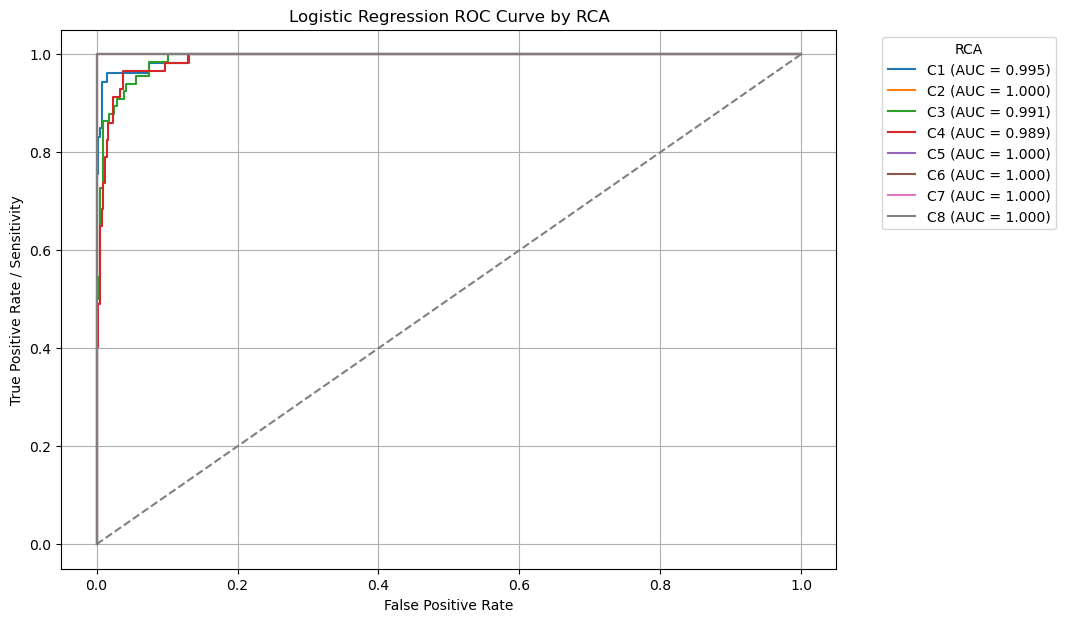

In [68]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Class labels
classes = log_model.classes_

# Binarize y_test for One-vs-Rest ROC
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
y_score = probs

plt.figure(figsize=(10, 7))

roc_auc_dict = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)
    roc_auc_dict[cls] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title("Logistic Regression ROC Curve by RCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

AUC ≈ 0.99–1.00 for almost every class with baseline Logistic Regression. Which is suspiciously high. There might be data leakage here.


#### LR - Precision-recall curve plot

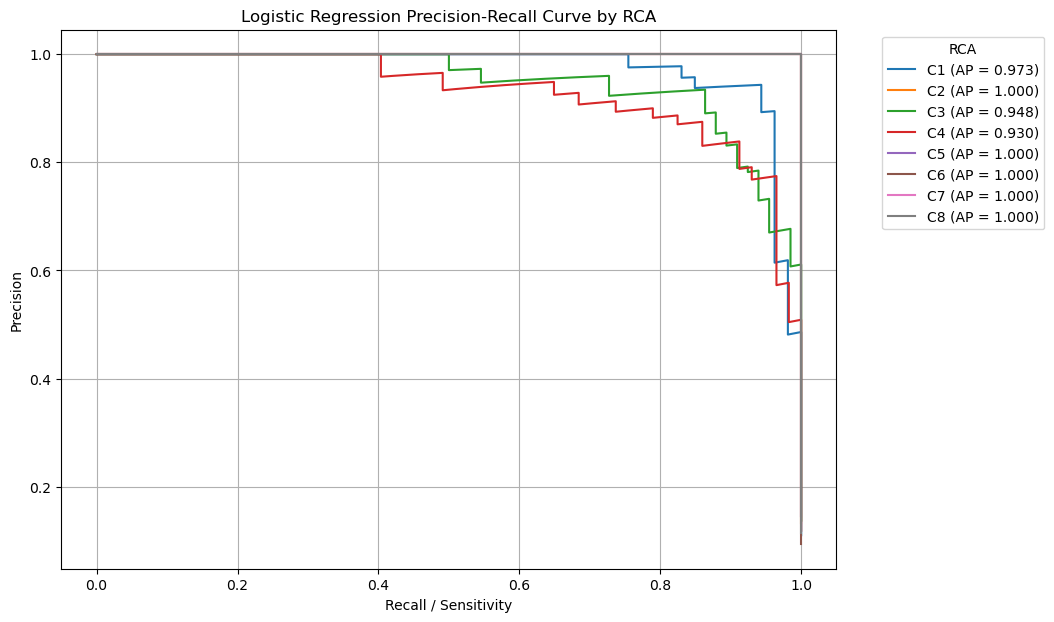

In [69]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

pr_auc_dict = {}

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

    pr_auc_dict[cls] = avg_precision

    plt.plot(
        recall,
        precision,
        label=f"{cls} (AP = {avg_precision:.3f})"
    )

plt.title("Logistic Regression Precision-Recall Curve by RCA")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend(title="RCA", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

#### Youden's J

In [70]:
from sklearn.metrics import confusion_matrix
import pandas as pd

youden_results = []

for cls in classes:
    # One-vs-rest conversion
    y_true_binary = (y_test == cls).astype(int)
    y_pred_binary = (preds == cls).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary,
        y_pred_binary
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    youden_results.append({
        "RCA": cls,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Youden_J": youden_j
    })

youden_df = pd.DataFrame(youden_results)

display(
    youden_df.sort_values(
        "Youden_J",
        ascending=False
    ).round(3)
)

,RCA,Sensitivity,Specificity,Youden_J
1,C2,1.000,1.000,1.000
4,C5,1.000,1.000,1.000
5,C6,1.000,1.000,1.000
6,C7,1.000,1.000,1.000
7,C8,1.000,1.000,1.000
0,C1,0.887,0.993,0.880
2,C3,0.879,0.976,0.855
3,C4,0.860,0.979,0.838


### LR - Confusion Matrix

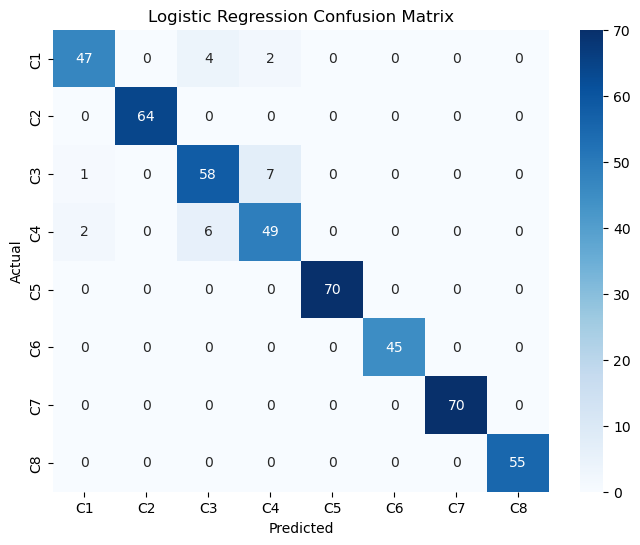

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Confusion Matrix Observations – Logistic Regression

* **Overall classification performance was strong**, achieving approximately **94.5% accuracy and macro F1**, suggesting that engineered telecom KPIs effectively distinguish RCA categories.

* **C2 (Coverage Overshooting) was perfectly classified** with **100% precision and recall**, indicating that overshooting scenarios exhibit a highly distinctive KPI signature, particularly through serving distance features.

* **C5 and C7 also achieved near-perfect classification**, suggesting that mobility and handover-related degradation mechanisms are highly separable from other RCA categories.

* **C6 (PCI Conflict) demonstrated excellent performance** (**Precision = 0.98, Recall = 1.00**), supporting the effectiveness of modulo-30 PCI conflict features (`same_mod30_ratio`, `same_mod30_count`) for identifying interference-related RCA.

* **C8 (Resource Insufficiency) was perfectly identified**, reinforcing EDA findings that RB-related features create a distinct degradation pattern.

* **The model struggled most with C1, C3, and C4**, where moderate confusion was observed between categories.

* **C3 and C4 showed the highest overlap**, indicating that neighboring-cell throughput issues and overlapping coverage may exhibit similar telecom KPI behavior, making separation more challenging for a linear model.

* **C1 occasionally overlapped with C3/C4**, suggesting that some tilt-related scenarios may share characteristics with neighboring-cell or overlap-driven degradation.

* Despite a very high **ROC-AUC (~0.996)**, the confusion matrix suggests that some RCA mechanisms remain operationally similar, highlighting opportunities for **nonlinear models (e.g., XGBoost, LightGBM)** to further improve separation among overlapping classes.


### LR - Classification Report

In [72]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

          C1       0.94      0.89      0.91        53
          C2       1.00      1.00      1.00        64
          C3       0.85      0.88      0.87        66
          C4       0.84      0.86      0.85        57
          C5       1.00      1.00      1.00        70
          C6       1.00      1.00      1.00        45
          C7       1.00      1.00      1.00        70
          C8       1.00      1.00      1.00        55

    accuracy                           0.95       480
   macro avg       0.95      0.95      0.95       480
weighted avg       0.95      0.95      0.95       480



### Checking for any data leakage as we are seeing high accuaracy and high RPC and precisions for each classes. 

In [73]:
coef_df = pd.DataFrame(
    log_model.coef_.T,
    index=X_encoded.columns,
    columns=log_model.classes_
)

coef_df.abs().max(axis=1)\
    .sort_values(ascending=False)\
    .head(20)

same_mod30_ratio          1.896729
neighbor_competition      1.847955
min_throughput            1.835494
avg_throughput_low_tp     1.828655
same_mod30_count          1.760259
avg_neighbor_advantage    1.558806
handover_count            1.427563
handover_rate             1.427563
pct_speed_above_40        1.397057
min_rsrp                  1.110400
std_throughput            1.038213
handover_count_low_tp     1.017273
avg_speed_low_tp          1.003649
max_speed                 0.977412
pct_rb_below_160          0.958386
avg_rsrp                  0.948177
avg_serving_height        0.900495
max_speed_low_tp          0.887403
avg_rb_low_tp             0.848586
max_serving_tilt          0.796980
dtype: float64

Although the Logistic Regression model achieved near-perfect performance, this appears to be a case of **domain-rule leakage rather than traditional data leakage**. Traditional data leakage occurs when information from the target variable or test set is unintentionally exposed to the model during training. In contrast, our engineered features were intentionally derived from domain knowledge and closely reflect the RCA definitions provided in the TeleLogs framework. For example, features such as `same_mod30_ratio`, `overlap_ratio`, `handover_count`, and `pct_rb_below_160` directly correspond to predefined RCA mechanisms such as PCI mod 30 conflict, overlapping coverage, frequent handovers, and insufficient RB allocation. As a result, the model is not memorizing hidden labels or test information, but rather learning structured telecom troubleshooting rules embedded in the feature space. This explains the unusually strong baseline performance and suggests that the model is effectively leveraging engineered telecom expertise to infer root causes.


### LR - Internal CV

Macro-averaged evaluation metrics were used to ensure that all RCA categories contributed equally to model performance, regardless of class frequency. Since the objective of RCA classification is to reliably identify all failure mechanisms rather than favor majority classes, macro averaging provides a more balanced assessment of predictive performance across root causes.

In [79]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# -----------------------------
# X and y
# -----------------------------

X = ml_df.drop("answer", axis=1).copy()

# Force categorical columns to plain Python strings
for col in ["txrx_mode", "antenna_model"]:
    if col in X.columns:
        X[col] = X[col].astype("object").fillna("Missing").astype(str)

# Force numeric columns to numeric
for col in X.columns:
    if col not in ["txrx_mode", "antenna_model"]:
        X[col] = pd.to_numeric(X[col], errors="coerce")

y = ml_df["answer"].astype(str)

# -----------------------------
# Columns
# -----------------------------

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = ["txrx_mode", "antenna_model"]

print(X.dtypes.value_counts())
print("Numeric:", len(numeric_cols))
print("Categorical:", categorical_cols)

# -----------------------------
# Preprocessing
# -----------------------------

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# -----------------------------
# Model
# -----------------------------

log_model_cv = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42,
    solver="lbfgs"
)

log_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", log_model_cv)
    ]
)

# -----------------------------
# CV
# -----------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

cv_results = cross_validate(
    log_pipeline,
    X,
    y,
    scoring=scoring,
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    error_score="raise"
)

# -----------------------------
# Results
# -----------------------------

for metric in scoring.keys():
    train_scores = cv_results[f"train_{metric}"]
    test_scores = cv_results[f"test_{metric}"]

    print(metric)
    print(f"  Train: {np.mean(train_scores):.3f} ({np.std(train_scores):.3f})")
    print(f"  Test : {np.mean(test_scores):.3f} ({np.std(test_scores):.3f})")
    print("-" * 40)

float64    38
int64       9
str         2
Name: count, dtype: int64
Numeric: 47
Categorical: ['txrx_mode', 'antenna_model']
accuracy
  Train: 0.964 (0.002)
  Test : 0.949 (0.008)
----------------------------------------
precision_macro
  Train: 0.963 (0.002)
  Test : 0.948 (0.009)
----------------------------------------
recall_macro
  Train: 0.964 (0.002)
  Test : 0.948 (0.008)
----------------------------------------
f1_macro
  Train: 0.963 (0.002)
  Test : 0.948 (0.009)
----------------------------------------
roc_auc_ovr
  Train: 0.998 (0.000)
  Test : 0.996 (0.000)
----------------------------------------


**Logistic Regression Baseline**

Even a simple interpretable model achieved:

94.5% F1
99.6% ROC-AUC

suggesting:

**telecom RCA mechanisms are strongly explainable through engineered KPIs.**

However:

C3/C4/C1

showed higher confusion due to overlapping telecom behavior.

While:

C2/C5/C6/C7/C8

were highly distinguishable.

#### Assumption check
##### 1. Multicolinearity

In [104]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# numeric only
X_num = X_encoded.select_dtypes(include=np.number)

vif_df = pd.DataFrame()
vif_df["Feature"] = X_num.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X_num.values, i
    )
    for i in range(X_num.shape[1])
]

vif_df = vif_df.sort_values(
    "VIF",
    ascending=False
)

vif_df.head(50)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
3,low_tp_count,inf
4,low_tp_ratio,inf
12,handover_count,inf
13,handover_rate,inf
11,num_unique_serving_pci,2.721544e+04
46,tilt_rsrp_interaction,2.142030e+03
38,avg_serving_tilt,2.086583e+03
44,pct_distance_gt_1km,8.415125e+02
43,max_serving_distance_km,6.498896e+02
45,avg_distance_low_tp,5.044539e+02


Variance Inflation Factor (VIF) analysis revealed substantial multicollinearity among engineered telecom features, particularly within groups describing similar network behaviors (e.g., handover activity, SINR quality, serving distance, RB allocation, and low-throughput periods). Several variables exhibited extremely high or infinite VIF values due to mathematical dependence or strong conceptual overlap (e.g., `handover_count` and `handover_rate`, `low_tp_count` and `low_tp_ratio`). While multicollinearity may reduce coefficient interpretability in Logistic Regression, it is less problematic for predictive performance, as reflected by stable internal cross-validation results. Since the primary objective of this study is RCA prediction rather than coefficient inference, correlated telecom KPIs were retained to preserve domain-relevant signal for downstream machine learning models.


#### 2. Linear relationship with log-odds

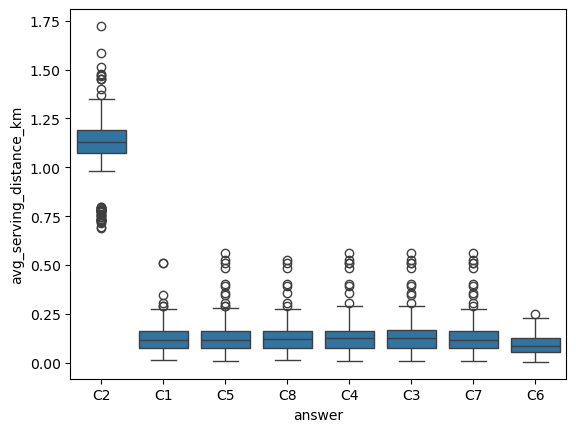

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=ml_df,
    x="answer",
    y="avg_serving_distance_km"
)

plt.show()

#### 3. No extreme class imbalance

#### 4. Independence of observations ⚠️
We will assume that each observation is independent to each other.

In [106]:
X_encoded.describe().T[
    ["min","25%","50%","75%","max"]
]

,min,25%,50%,75%,max
avg_throughput,504.807000,640.596000,711.197000,819.266000,1197.858000
min_throughput,0.000000,190.530000,273.540000,374.910000,665.300000
std_throughput,180.387110,302.501276,355.970841,409.940624,607.363614
low_tp_count,0.000000,4.000000,4.000000,4.000000,4.000000
low_tp_ratio,0.000000,0.400000,0.400000,0.400000,0.400000
avg_throughput_low_tp,45.830000,263.658125,340.105000,431.155000,593.750000
consecutive_low_tp_max,0.000000,4.000000,4.000000,4.000000,4.000000
max_speed,22.000000,35.000000,37.000000,39.000000,79.000000
pct_speed_above_40,0.000000,0.000000,0.000000,0.000000,0.400000
avg_speed_low_tp,2.000000,16.000000,20.750000,26.500000,77.250000


Descriptive statistics did not indicate substantial extreme outliers that would likely distort Logistic Regression performance. Although some variables exhibited wider ranges (e.g., serving distance and PCI-related features), these observations reflect meaningful telecom behaviors associated with RCA mechanisms (e.g., coverage overshooting or PCI conflict) rather than data quality issues. Therefore, potentially extreme values were retained to preserve operational signal relevant for root cause classification.


### VIF

In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd
import numpy as np

# ============================================================
# Use FULL one-hot encoded train dataset
# ============================================================

X_vif = X_encoded.copy()

# Make everything numeric
X_vif = X_vif.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace inf values
X_vif = X_vif.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values
X_vif = X_vif.fillna(
    X_vif.median()
)

# Convert all to float
X_vif = X_vif.astype(float)

# ============================================================
# Add intercept / constant
# ============================================================

X_vif_const = sm.add_constant(
    X_vif,
    has_constant="add"
)

# ============================================================
# Calculate VIF
# ============================================================

vif_df = pd.DataFrame()

vif_df["Feature"] = X_vif_const.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X_vif_const.values.astype(float),
        i
    )
    for i in range(
        X_vif_const.shape[1]
    )
]

# Sort high → low
vif_df = vif_df.sort_values(
    "VIF",
    ascending=False
)

# Display
display(
    vif_df.round(3)
)

# Optional: only high VIF variables
high_vif = vif_df[
    vif_df["VIF"] > 10
]

print("\nHigh VIF Variables (>10):")
display(
    high_vif.round(3)
)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
45,pct_distance_gt_1km,inf
4,low_tp_count,inf
5,low_tp_ratio,inf
12,num_unique_serving_pci,inf
13,handover_count,inf
14,handover_rate,inf
47,tilt_rsrp_interaction,2169.790
39,avg_serving_tilt,2111.598
44,max_serving_distance_km,665.628
46,avg_distance_low_tp,517.911



High VIF Variables (>10):


,Feature,VIF
45,pct_distance_gt_1km,inf
4,low_tp_count,inf
5,low_tp_ratio,inf
12,num_unique_serving_pci,inf
13,handover_count,inf
14,handover_rate,inf
47,tilt_rsrp_interaction,2169.790
39,avg_serving_tilt,2111.598
44,max_serving_distance_km,665.628
46,avg_distance_low_tp,517.911


In [89]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd
import numpy as np

# -----------------------------
# Columns to drop due to redundancy / high VIF
# -----------------------------

drop_vif_cols = [
    "low_tp_count",
    "low_tp_ratio",
    "consecutive_low_tp_max",
    "handover_count",
    "max_serving_distance_km",
    "avg_distance_low_tp",
    "avg_sinr_low_tp",
    "min_sinr",
    "avg_rb_low_tp",
    "min_rb_low_tp",
    "avg_serving_tilt",
    "min_sinr_low_tp",
    "std_throughput",
    "pct_distance_gt_1km"
    

]

# -----------------------------
# Create reduced encoded dataset
# -----------------------------

X_vif_reduced = X_encoded.copy()

X_vif_reduced = X_vif_reduced.drop(
    columns=[
        col for col in drop_vif_cols
        if col in X_vif_reduced.columns
    ]
)

# Make sure everything is numeric
X_vif_reduced = X_vif_reduced.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace inf values
X_vif_reduced = X_vif_reduced.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values
X_vif_reduced = X_vif_reduced.fillna(
    X_vif_reduced.median()
)

# Force float
X_vif_reduced = X_vif_reduced.astype(float)

# -----------------------------
# Add constant
# -----------------------------

X_vif_reduced_const = sm.add_constant(
    X_vif_reduced,
    has_constant="add"
)

# -----------------------------
# Recalculate VIF
# -----------------------------

vif_reduced_df = pd.DataFrame({
    "Feature": X_vif_reduced_const.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_reduced_const.values.astype(float),
            i
        )
        for i in range(
            X_vif_reduced_const.shape[1]
        )
    ]
})

vif_reduced_df = vif_reduced_df.sort_values(
    "VIF",
    ascending=False
)

display(
    vif_reduced_df.round(3)
)

# -----------------------------
# Show remaining high VIF
# -----------------------------

high_vif_reduced = vif_reduced_df[
    vif_reduced_df["VIF"] > 10
]

print("\nRemaining High VIF Variables (>10):")
display(
    high_vif_reduced.round(3)
)

print("\nOriginal number of features:", X_encoded.shape[1])
print("Reduced number of features:", X_vif_reduced.shape[1])

,Feature,VIF
0,const,7890.089
24,overlap_ratio,98.929
23,avg_close_neighbor_count,93.472
8,num_unique_serving_pci,28.636
17,avg_rb,21.089
27,same_mod30_ratio,19.388
10,handover_count_low_tp,19.190
9,handover_rate,16.546
32,avg_serving_distance_km,16.412
18,min_rb,16.314



Remaining High VIF Variables (>10):


,Feature,VIF
0,const,7890.089
24,overlap_ratio,98.929
23,avg_close_neighbor_count,93.472
8,num_unique_serving_pci,28.636
17,avg_rb,21.089
27,same_mod30_ratio,19.388
10,handover_count_low_tp,19.190
9,handover_rate,16.546
32,avg_serving_distance_km,16.412
18,min_rb,16.314



Original number of features: 50
Reduced number of features: 36


### External Cross Validation with test data set

In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import json
import pandas as pd
import numpy as np

# ============================================================
# 1. Refit Logistic Regression on FULL train.json
# ============================================================

# X_encoded and y should come from full train.json
X_full_train = X_encoded.copy()
y_full_train = y.copy()

# Convert all columns to numeric
X_full_train = X_full_train.apply(
    pd.to_numeric,
    errors="coerce"
)

# Impute using FULL train medians
train_medians = X_full_train.median()

X_full_train = X_full_train.fillna(
    train_medians
)

# Scale using FULL train.json only
scaler = StandardScaler()

X_full_train_scaled = scaler.fit_transform(
    X_full_train
)

# Refit final Logistic Regression model
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42,
    solver="lbfgs"
)

log_model.fit(
    X_full_train_scaled,
    y_full_train
)

print("Final Logistic Regression model refit on 100% of train.json")
print("Training shape:", X_full_train.shape)

# ============================================================
# 2. Get Top 10 Logistic Regression Coefficients by RCA
# ============================================================

coef_df = pd.DataFrame(
    log_model.coef_.T,
    index=X_full_train.columns,
    columns=log_model.classes_
)

coef_long = (
    coef_df
    .reset_index()
    .melt(
        id_vars="index",
        var_name="RCA",
        value_name="Coefficient"
    )
    .rename(
        columns={
            "index": "Feature"
        }
    )
)

coef_long["Abs_Coefficient"] = (
    coef_long["Coefficient"]
    .abs()
)

coef_long = coef_long.sort_values(
    ["RCA", "Abs_Coefficient"],
    ascending=[True, False]
)

top_coef_by_rca = (
    coef_long
    .groupby("RCA")
    .head(10)
    .reset_index(drop=True)
)

# Display top 10 features by RCA
for rca in top_coef_by_rca["RCA"].unique():

    print("=" * 60)
    print(f"Top Features for {rca}")
    print("=" * 60)

    display(
        top_coef_by_rca[
            top_coef_by_rca["RCA"] == rca
        ].round(4)
    )

# ============================================================
# 3. Load external test.json
# ============================================================

with open("../data/test.json", "r") as f:
    test = json.load(f)

# ============================================================
# 4. Apply same feature engineering used for train.json
# ============================================================

test_rows = []

for item in test:
    user_df, eng_df = parse_tables(item["question"])
    features = make_features(user_df, eng_df)
    features["answer"] = item["answer"]
    test_rows.append(features)

test_df = pd.DataFrame(test_rows)

print("\nExternal test shape:", test_df.shape)
display(test_df.head())

# ============================================================
# 5. Separate predictors and target
# ============================================================

X_test_external = test_df.drop(
    columns=["answer"]
)

y_test_external = test_df["answer"]

# ============================================================
# 6. One-hot encode categorical variables
# ============================================================

X_test_external = pd.get_dummies(
    X_test_external,
    drop_first=True
)

# ============================================================
# 7. Match FULL training columns exactly
# ============================================================

X_test_external = X_test_external.reindex(
    columns=X_full_train.columns,
    fill_value=0
)

# ============================================================
# 8. Convert all columns to numeric
# ============================================================

X_test_external = X_test_external.apply(
    pd.to_numeric,
    errors="coerce"
)

# ============================================================
# 9. Impute missing values using FULL TRAIN medians
# ============================================================

X_test_external = X_test_external.fillna(
    train_medians
)

# ============================================================
# 10. Safety checks
# ============================================================

print("\nColumn match:",
      X_test_external.columns.equals(
          X_full_train.columns
      ))

print("Remaining missing values:",
      X_test_external.isna().sum().sum())

print("Non-numeric columns:",
      X_test_external.select_dtypes(
          include=["object", "category"]
      ).columns.tolist())

# ============================================================
# 11. Scale external test using SAME scaler fitted on FULL train
# ============================================================

X_test_external_scaled = scaler.transform(
    X_test_external
)

# ============================================================
# 12. Predict external test
# ============================================================

external_preds = log_model.predict(
    X_test_external_scaled
)

external_probs = log_model.predict_proba(
    X_test_external_scaled
)

# ============================================================
# 13. External evaluation
# ============================================================

print("\nExternal Test Accuracy:")
print(
    accuracy_score(
        y_test_external,
        external_preds
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_external,
        external_preds,
        labels=log_model.classes_
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_external,
        external_preds,
        labels=log_model.classes_
    )
)

Final Logistic Regression model refit on 100% of train.json
Training shape: (2400, 50)
Top Features for C1


,Feature,RCA,Coefficient,Abs_Coefficient
0,avg_neighbor_advantage,C1,-1.6193,1.6193
1,min_rsrp,C1,-1.1994,1.1994
2,avg_throughput_low_tp,C1,-1.0666,1.0666
3,min_throughput,C1,1.0591,1.0591
4,avg_serving_height,C1,-0.9508,0.9508
5,neighbor_competition,C1,0.9080,0.9080
6,avg_rsrp,C1,-0.8209,0.8209
7,max_neighbor_advantage,C1,0.7985,0.7985
8,same_mod30_ratio,C1,-0.6590,0.6590
9,max_speed,C1,-0.6229,0.6229


Top Features for C2


,Feature,RCA,Coefficient,Abs_Coefficient
10,num_unique_serving_pci,C2,0.8154,0.8154
11,pct_distance_gt_1km,C2,0.8154,0.8154
12,avg_distance_low_tp,C2,0.7055,0.7055
13,max_serving_distance_km,C2,0.6941,0.6941
14,avg_serving_distance_km,C2,0.6673,0.6673
15,handover_count_low_tp,C2,-0.3475,0.3475
16,handover_count,C2,0.3309,0.3309
17,handover_rate,C2,0.3309,0.3309
18,max_neighbor_advantage,C2,-0.1628,0.1628
19,avg_neighbor_advantage,C2,-0.1434,0.1434


Top Features for C3


...

Top Features for C8


,Feature,RCA,Coefficient,Abs_Coefficient
70,pct_rb_below_160,C8,1.0062,1.0062
71,avg_rb_low_tp,C8,-0.8600,0.8600
72,avg_rb,C8,-0.7380,0.7380
73,min_rb_low_tp,C8,-0.7350,0.7350
74,min_rb,C8,-0.7232,0.7232
75,neighbor_competition,C8,0.1395,0.1395
76,min_throughput,C8,0.1373,0.1373
77,max_neighbor_advantage,C8,-0.1091,0.1091
78,avg_neighbor_advantage,C8,-0.0861,0.0861
79,overlap_ratio,C8,-0.0709,0.0709



External test shape: (864, 50)


,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,avg_serving_tilt,max_serving_tilt,avg_serving_beamwidth,avg_serving_height,avg_serving_distance_km,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,tilt_rsrp_interaction,answer
0,642.122,0.14,480.631072,4,0.4,118.835,4,38,0.0,24.75,...,19.0,40,10.2,10.8,0.035405,0.058137,0.0,0.025289,1673.330,C1
1,642.122,0.14,480.631072,4,0.4,118.835,4,38,0.0,24.75,...,12.6,16,9.0,42.0,1.294696,3.190474,0.4,3.185259,1109.682,C2
2,682.122,0.14,448.967513,4,0.4,218.835,4,38,0.0,24.75,...,10.6,12,10.2,10.8,0.035405,0.058137,0.0,0.025289,933.542,C3
3,642.122,0.14,480.631072,4,0.4,118.835,4,38,0.0,24.75,...,10.6,12,10.2,10.8,0.035405,0.058137,0.0,0.025289,933.542,C4
4,642.122,0.14,480.631072,4,0.4,118.835,4,38,0.0,24.75,...,10.6,12,10.2,10.8,0.035414,0.058137,0.0,0.025312,933.542,C5



Column match: True
Remaining missing values: 0
Non-numeric columns: []

External Test Accuracy:
0.9432870370370371

Confusion Matrix:
[[ 96   0   6   6   0   0   0   0]
 [  0 108   0   0   0   0   0   0]
 [  6   0  97   5   0   0   0   0]
 [  3   0  22  82   0   1   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [  0   0   0   0   0   0   0 108]]

Classification Report:
              precision    recall  f1-score   support

          C1       0.91      0.89      0.90       108
          C2       1.00      1.00      1.00       108
          C3       0.78      0.90      0.83       108
          C4       0.88      0.76      0.82       108
          C5       1.00      1.00      1.00       108
          C6       0.99      1.00      1.00       108
          C7       1.00      1.00      1.00       108
          C8       1.00      1.00      1.00       108

    accuracy                           0.94       864
   macro avg      

In [25]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Classification report as dictionary
report = classification_report(
    y_test_external,
    external_preds,
    output_dict=True
)

# Convert to dataframe
metrics_df = pd.DataFrame(report).transpose()

# Add overall accuracy
metrics_df.loc["accuracy", "precision"] = accuracy_score(
    y_test_external,
    external_preds
)

# Round values
metrics_df = metrics_df.round(3)

metrics_df

summary_metrics = pd.DataFrame({
    "Metric": [
        "External Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score",
        "Weighted F1 Score"
    ],
    "Value": [
        accuracy_score(y_test_external, external_preds),
        report["macro avg"]["precision"],
        report["macro avg"]["recall"],
        report["macro avg"]["f1-score"],
        report["weighted avg"]["f1-score"]
    ]
})

summary_metrics = summary_metrics.round(3)
summary_metrics

,Metric,Value
0,External Accuracy,0.943
1,Macro Precision,0.945
2,Macro Recall,0.943
3,Macro F1 Score,0.943
4,Weighted F1 Score,0.943


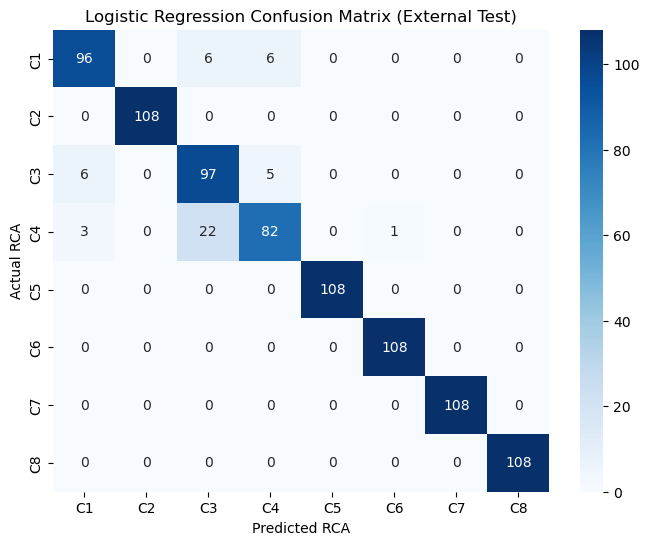

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(
    y_test_external,
    external_preds,
    labels=log_model.classes_
)

# -----------------------------
# Plot Heatmap
# -----------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.title(
    "Logistic Regression Confusion Matrix (External Test)"
)

plt.xlabel("Predicted RCA")
plt.ylabel("Actual RCA")

plt.show()